# MNIST Digit Recognition

This notebook builds a handwritten digit recognition system on MNIST. It includes an ANN baseline and a CNN extension in one clean workflow.

## 1. Problem Statement

Goal: classify handwritten digits from 0 to 9 using the MNIST dataset.

This notebook follows the required order:

1. Problem Statement
2. Dataset
3. Preprocessing
4. Visualization
5. Model
6. Training
7. Evaluation
8. Visual Confusion Heatmap
9. Precision & Reacall
10. Interept which digits are misclassified and why

## 2. Dataset

MNIST provides a fixed train/test split:

- 60,000 training images
- 10,000 testing images
- Image size: 28 x 28 grayscale
- Classes: 10 digits (0-9)

In [2]:
# Disable oneDNN optimization warning (optional)
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Train label shape:", y_train.shape)
print("Test label shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Train label shape: (60000,)
Test label shape: (10000,)


## 3. Preprocessing

Before feeding data into a neural network, raw image data must be
prepared carefully. This section performs three essential steps:

**1. Normalization (Dividing by 255)**
Raw MNIST images have pixel values ranging from 0 to 255.
Dividing by 255 scales all values to a range of 0 to 1.
This is important because:
- Neural networks train faster with small, uniform input values
- Large input values cause large weight updates which make
  training unstable
- Normalized data helps the Adam optimizer converge smoothly

**2. Reshaping**
The original images are 28×28 pixel grids (2D).
- For ANN: the image is flattened into a 784-length 1D vector
  because ANN's Dense layers expect a flat input
- For CNN: the image keeps its 28×28 shape but gets an extra
  dimension (28×28×1) because CNN layers expect 3D input
  (height × width × color channels)

**3. One-Hot Encoding**
Labels like 5 are converted into [0,0,0,0,0,1,0,0,0,0].
This is required because our output layer has 10 neurons
(one per digit) and categorical crossentropy loss expects
this format to calculate error correctly.

In [4]:
# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalized training data range:", X_train.min(), "to", X_train.max())
print("Normalized testing data range:", X_test.min(), "to", X_test.max())

# Reshape for ANN: 28 x 28 -> 784
X_train_ann = X_train.reshape(-1, 784)
X_test_ann = X_test.reshape(-1, 784)

# Reshape for CNN: 28 x 28 -> 28 x 28 x 1
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels for multi-class classification
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("ANN training shape:", X_train_ann.shape)
print("ANN testing shape:", X_test_ann.shape)
print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)
print("Encoded label shape:", y_train_encoded.shape)

Normalized training data range: 0.0 to 1.0
Normalized testing data range: 0.0 to 1.0
ANN training shape: (60000, 784)
ANN testing shape: (10000, 784)
CNN training shape: (60000, 28, 28, 1)
CNN testing shape: (10000, 28, 28, 1)
Encoded label shape: (60000, 10)


## 4. Data Visualization
### Graph 1 - Sample Digit Images
This graph displays the first 5 images from the MNIST training set
along with their true labels.

**What it tells us:**
- It confirms the dataset is loaded correctly
- We can visually verify that labels match the actual digit shown
- It gives us an intuition of what the model needs to learn —
  handwritten digits vary in size, stroke thickness, and angle
- This variation is exactly why machine learning is needed —
  simple rule-based systems cannot handle such diversity


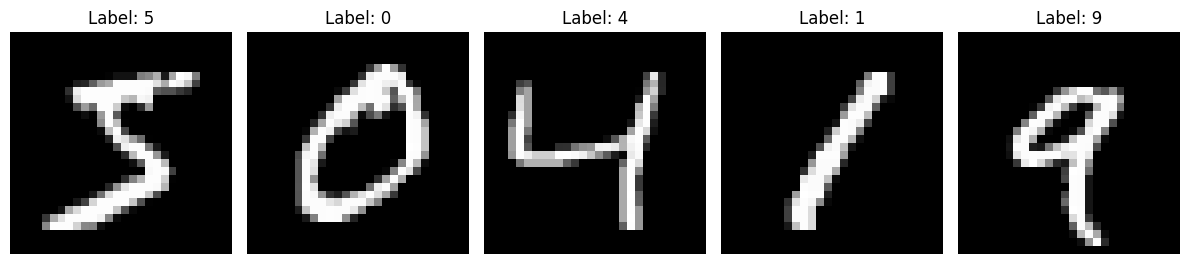

In [5]:
# Sample digit images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i], cmap="gray")
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Graph 2 - Digit Distribution Bar Chart

This bar chart shows how many times each digit (0–9) appears
in the MNIST training set.

**What it tells us:**
- The dataset is fairly balanced — each digit appears roughly
  5,000 to 6,500 times
- A balanced dataset is important because if one digit had
  far more samples than others, the model would be biased
  toward predicting that digit more often
- Since MNIST is well balanced, our model can learn each digit
  equally well without any special balancing techniques

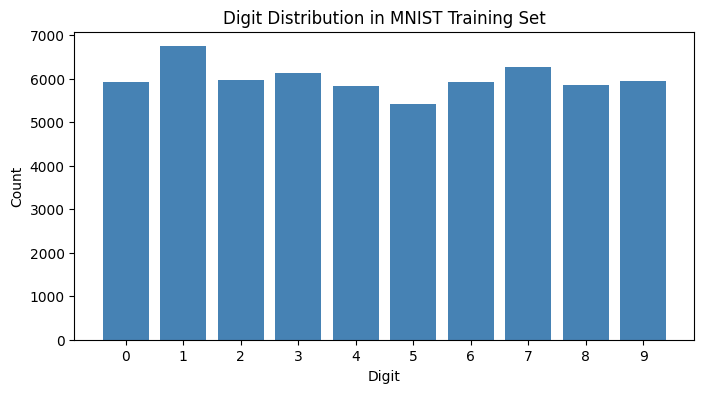

In [6]:
# Digit distribution bar chart
digit_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(8, 4))
plt.bar(np.arange(10), digit_counts, color="steelblue")
plt.xticks(np.arange(10))
plt.title("Digit Distribution in MNIST Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

### Graph 3 - Pixel Intensity Histogram

This histogram shows the frequency of pixel values across
all training images after normalization (values between 0 and 1).

**What it tells us:**
- The majority of pixels have a value close to 0 (black background)
  This makes sense because MNIST digits are white strokes on
  a black background — most of the image is empty background
- A smaller number of pixels have high values (close to 1)
  representing the actual digit strokes
- This distribution confirms that normalization worked correctly
  and pixel values are properly scaled between 0 and 1

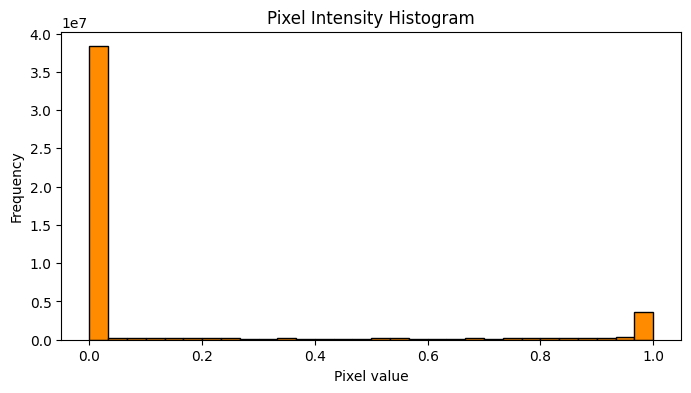

In [7]:
# Pixel intensity histogram
plt.figure(figsize=(8, 4))
plt.hist(X_train.flatten(), bins=30, color="darkorange", edgecolor="black")
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.show()

## 5. ANN Model

Architecture:

- Input layer: 784 neurons
- Hidden layer 1: 128 neurons with ReLU
- Hidden layer 2: 64 neurons with ReLU
- Output layer: 10 neurons with softmax

In [8]:
model_ann = Sequential()
model_ann.add(Dense(128, activation="relu", input_shape=(784,)))
model_ann.add(Dense(64, activation="relu"))
model_ann.add(Dense(10, activation="softmax"))

model_ann.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("ANN Model Summary:")
model_ann.summary()

ANN Model Summary:


e:\Spring Boot Journey\Ml\1\ML LABMID\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. ANN Training
### Training Accuracy & Loss Graphs

These two graphs show how the model learned over 10 epochs.

**Accuracy Graph:**
- Training accuracy should increase each epoch as the model learns
- Validation accuracy should follow closely — if it stays close
  to training accuracy, the model is generalizing well
- A large gap between train and validation accuracy means
  overfitting (model memorized training data)

**Loss Graph:**
- Training loss should decrease each epoch
- Validation loss should also decrease and stay close to
  training loss
- If validation loss starts increasing while training loss
  decreases, that is a sign of overfitting

In [9]:
ANN_EPOCHS = 10
ANN_BATCH_SIZE = 32

history_ann = model_ann.fit(
    X_train_ann, y_train_encoded,
    epochs=ANN_EPOCHS,
    batch_size=ANN_BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9221 - loss: 0.2709 - val_accuracy: 0.9561 - val_loss: 0.1466
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9657 - loss: 0.1158 - val_accuracy: 0.9623 - val_loss: 0.1333
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9749 - loss: 0.0802 - val_accuracy: 0.9650 - val_loss: 0.1148
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0607 - val_accuracy: 0.9685 - val_loss: 0.1003
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0464 - val_accuracy: 0.9729 - val_loss: 0.0945
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9882 - loss: 0.0372 - val_accuracy: 0.9728 - val_loss: 0.0950
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9896 - loss: 0.0319 - val_accuracy: 0.9732 - val_loss: 0.0973
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0261 - 

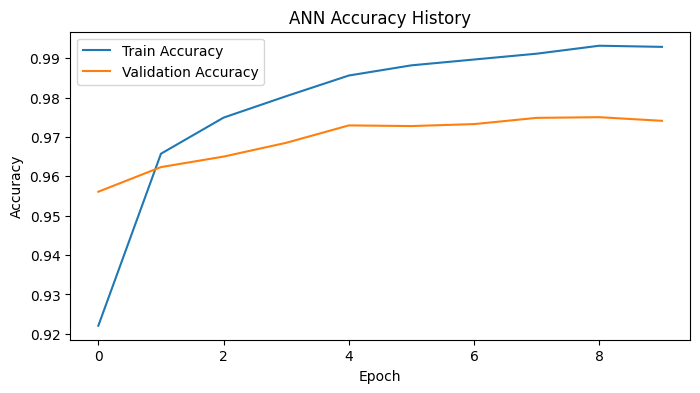

In [10]:
# Accuracy Graph
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history["accuracy"], label="Train Accuracy")
plt.plot(history_ann.history["val_accuracy"], label="Validation Accuracy")
plt.title("ANN Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

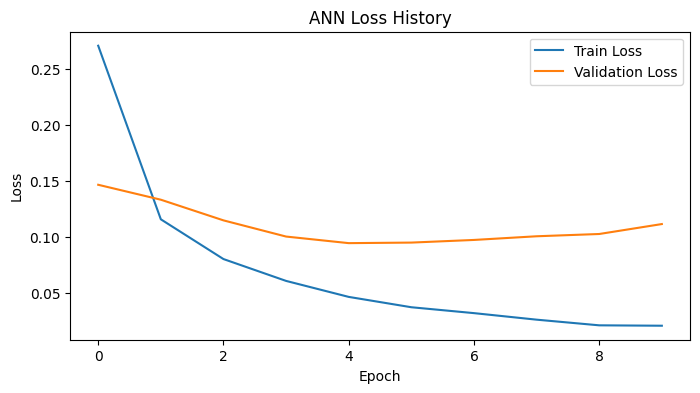

In [11]:
# Loss Graph
plt.figure(figsize=(8, 4))
plt.plot(history_ann.history["loss"], label="Train Loss")
plt.plot(history_ann.history["val_loss"], label="Validation Loss")
plt.title("ANN Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 7. ANN Evaluation
1. ANN CONFUSION MATRIX
2. ANN CLASSIFICATION REPORT

In [12]:
y_pred_ann = model_ann.predict(X_test_ann, verbose=0)
y_pred_ann_classes = np.argmax(y_pred_ann, axis=1)
ann_confusion = confusion_matrix(y_test, y_pred_ann_classes)

print("ANN Confusion Matrix:")
print(ann_confusion)

ANN Confusion Matrix:
[[ 964    0    0    2    0    2    3    3    4    2]
 [   0 1112    3    1    0    0    2    2   15    0]
 [   5    0  992   12    1    0    3    8   11    0]
 [   2    0    2  988    0    9    0    3    3    3]
 [   0    1    4    0  933    0    5    2    6   31]
 [   2    1    0   10    0  873    4    0    1    1]
 [   2    2    0    1    2   14  935    1    1    0]
 [   0    1    7    4    0    0    0 1004    3    9]
 [   0    0    0    6    0    4    2    1  957    4]
 [   3    2    1   10    5    3    0    2    6  977]]


In [13]:
ann_loss, ann_acc = model_ann.evaluate(X_test_ann, y_test_encoded, verbose=0)
print("ANN CLassification Report: ")
print(f"ANN Test Loss: {ann_loss:.4f}")
print(f"ANN Test Accuracy: {ann_acc:.4f}")

ANN CLassification Report: 
ANN Test Loss: 0.1024
ANN Test Accuracy: 0.9735


## 8. CNN Model Architecture
A Convolutional Neural Network (CNN) is specially designed for
image data. Unlike ANN which flattens the image, CNN preserves
the 2D spatial structure and scans for features using filters.

**Our CNN has 7 layers:**

- **Conv2D Layer 1 (32 filters, 3×3 kernel, ReLU):**
  Scans the image with 32 different filters to detect low-level
  features like edges, corners, and curves.

- **MaxPooling Layer 1 (2×2):**
  Reduces the spatial size by half, keeping only the strongest
  features. This reduces computation and prevents overfitting.

- **Conv2D Layer 2 (64 filters, 3×3 kernel, ReLU):**
  Detects more complex patterns by combining features found
  in the first conv layer (e.g., loops, strokes).

- **MaxPooling Layer 2 (2×2):**
  Further reduces spatial size while retaining important features.

- **Flatten Layer:**
  Converts the 2D feature maps into a 1D vector so it can be
  passed into Dense layers.

- **Dense Layer (64 neurons, ReLU):**
  Combines all extracted features to make sense of the digit.

- **Output Layer (10 neurons, Softmax):**
  Same as ANN — outputs probabilities for each digit class.

**Why CNN beats ANN for images:**
ANN loses all spatial information by flattening pixels.
CNN scans the image in small windows preserving the relationship
between neighboring pixels — which is critical for recognizing
shapes in handwritten digits.


In [14]:
model_cnn = Sequential()
model_cnn.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation="relu"))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation="relu"))
model_cnn.add(Dense(10, activation="softmax"))

model_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN Model Summary:")
model_cnn.summary()

CNN Model Summary:


e:\Spring Boot Journey\Ml\1\ML LABMID\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 9. CNN Training
### Training Accuracy & Loss Graphs

These two graphs show how the model learned over 10 epochs.

**Accuracy Graph:**
- Training accuracy should increase each epoch as the model learns
- Validation accuracy should follow closely — if it stays close
  to training accuracy, the model is generalizing well
- A large gap between train and validation accuracy means
  overfitting (model memorized training data)

**Loss Graph:**
- Training loss should decrease each epoch
- Validation loss should also decrease and stay close to
  training loss
- If validation loss starts increasing while training loss
  decreases, that is a sign of overfitting

In [15]:
CNN_EPOCHS = 10
CNN_BATCH_SIZE = 32

history_cnn = model_cnn.fit(
    X_train_cnn, y_train_encoded,
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9518 - loss: 0.1557 - val_accuracy: 0.9818 - val_loss: 0.0589
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9842 - loss: 0.0509 - val_accuracy: 0.9837 - val_loss: 0.0532
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9891 - loss: 0.0337 - val_accuracy: 0.9869 - val_loss: 0.0457
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9919 - loss: 0.0253 - val_accuracy: 0.9891 - val_loss: 0.0398
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.9901 - val_loss: 0.0345
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9962 - loss: 0.0107 - val_accuracy: 0.9881 - val_loss: 0.0467
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9969 -

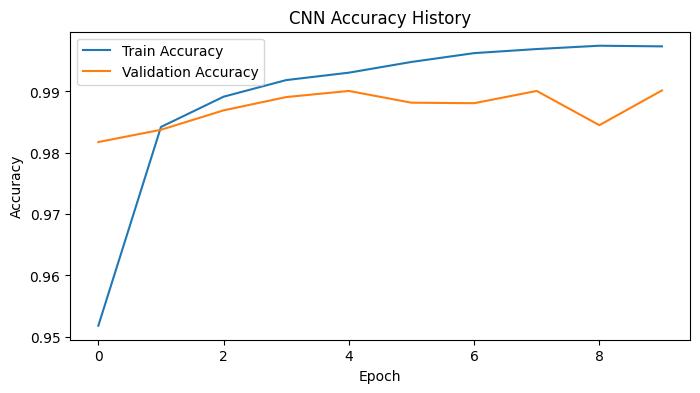

In [16]:
# CNN Accuracy History Graph
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

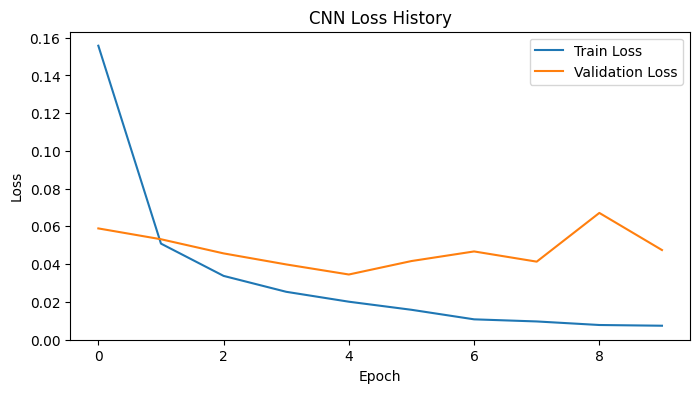

In [17]:
# CNN Loss History Graph
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10. CNN Evaluation

In [18]:
cnn_loss, cnn_acc = model_cnn.evaluate(X_test_cnn, y_test_encoded, verbose=0)
print ("CNN Classification Report: ")
print(f"CNN Test Loss: {cnn_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_acc:.4f}")

CNN Classification Report: 
CNN Test Loss: 0.0375
CNN Test Accuracy: 0.9901


In [19]:
y_pred_cnn = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)
cnn_confusion = confusion_matrix(y_test, y_pred_cnn_classes)

print("CNN Confusion Matrix:")
print(cnn_confusion)


CNN Confusion Matrix:
[[ 977    0    1    0    0    0    1    1    0    0]
 [   0 1132    1    1    1    0    0    0    0    0]
 [   2    1 1024    1    2    0    0    1    1    0]
 [   0    1    3 1003    0    3    0    0    0    0]
 [   0    0    0    0  970    0    2    0    1    9]
 [   0    0    0    7    0  881    1    0    1    2]
 [   4    2    0    0    1    5  946    0    0    0]
 [   0    2   10    1    0    1    0 1011    1    2]
 [   2    0    1    2    0    3    0    0  963    3]
 [   1    0    0    2    4    4    0    1    3  994]]


In [20]:
print("\nModel Accuracy Comparison:")
print(f"ANN Accuracy: {ann_acc:.4f}")
print(f"CNN Accuracy: {cnn_acc:.4f}")
print(f"Better Model: {'CNN' if cnn_acc > ann_acc else 'ANN'}")


Model Accuracy Comparison:
ANN Accuracy: 0.9735
CNN Accuracy: 0.9901
Better Model: CNN


## 11. Visual Confrontation Matrix Heatmap for ANN
The confusion matrix shows how well the ANN model classified each digit.
Each row represents the actual digit, and each column represents what the
model predicted.

- The diagonal cells (top-left to bottom-right) show correct predictions.
  Darker blue means more correct predictions for that digit.
- The off-diagonal cells show misclassifications. For example, if row 3,
  column 5 has a high number, it means the model confused digit 3 as digit 5.
- This helps us identify which digits are hardest to classify and why
  (e.g., digits 3 and 5 look similar, so the model may confuse them).


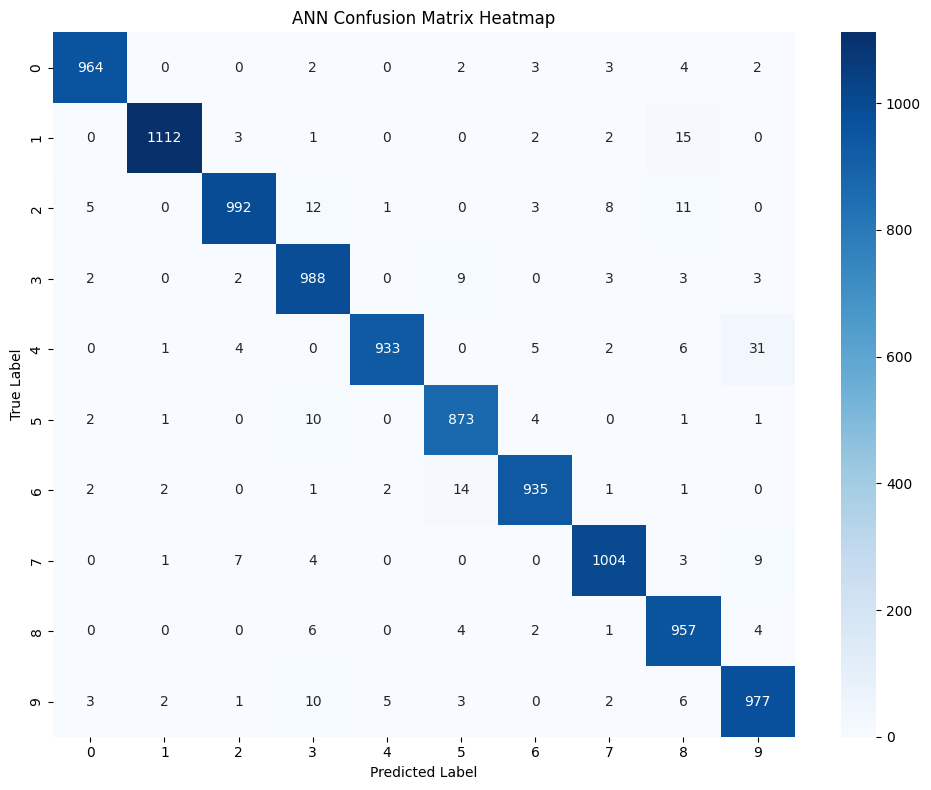

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(ann_confusion,annot=True,fmt='d',cmap='Blues',xticklabels=range(10),yticklabels=range(10))
plt.title('ANN Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 12. Precision & Recall for ANN
After visualizing the confusion matrix, we calculate Precision and Recall
for each digit class to get a deeper understanding of model performance.

- **Precision** tells us: when the model predicted a digit, how often was
  it correct? High precision means fewer false positives.

- **Recall** tells us: out of all real instances of a digit, how many did
  the model catch? High recall means fewer false negatives.

- **F1-Score** is the combined average of Precision and Recall. It is
  useful when we want a single number to judge per-class performance.

- **Support** is simply the number of actual test samples for each digit.

A digit with low Recall means the model struggles to recognize it.
A digit with low Precision means the model often confuses other digits with it.

In [22]:
print("ANN Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_ann_classes, target_names=[str(i) for i in range(10)]))

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.99      0.95      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.95      0.98      0.97       974
           9       0.95      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## 13. Visual Confusion Matrix Heatmap For CNN
This heatmap shows the CNN model's classification performance across
all 10 digit classes.

- Just like the ANN heatmap, the diagonal shows correct predictions.
  The greener and darker the diagonal, the better the model performed.

- Compared to the ANN heatmap, you will notice:
  - The diagonal is darker (more correct predictions)
  - The off-diagonal cells have smaller numbers (fewer mistakes)

- This visually proves that CNN performs better than ANN for image
  classification because CNN preserves the spatial structure of images
  while ANN treats each pixel independently.

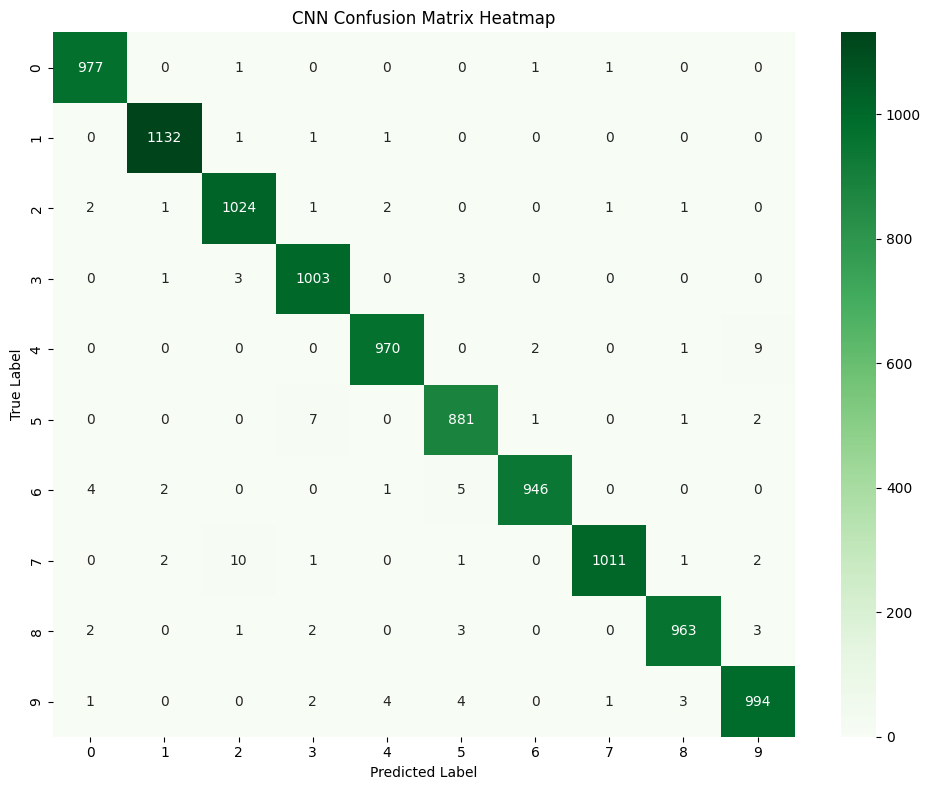

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(cnn_confusion,annot=True,fmt='d',cmap='Greens',xticklabels=range(10), yticklabels=range(10))
plt.title('CNN Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 14. Precision & Reacall for CNN
We now calculate the same Precision, Recall and F1-Score metrics for
the CNN model to allow direct comparison with the ANN results.

- A higher Precision means the CNN makes fewer false predictions
  per digit class compared to ANN.

- A higher Recall means the CNN misses fewer actual digit instances
  compared to ANN.

- The final comparison block shows the overall accuracy improvement
  from ANN to CNN, which demonstrates why CNNs are preferred for
  image-based classification tasks.

Key reason CNN outperforms ANN:
- ANN flattens the image into 784 pixels and loses all spatial
  information (position of strokes, curves, edges).
- CNN uses filters to scan the image and detect spatial features
  like edges, curves, and shapes — which are critical for recognizing
  handwritten digits.


In [24]:
print("CNN Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_cnn_classes, target_names=[str(i) for i in range(10)]))
# Side by side accuracy comparison
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(f"ANN Test Accuracy : {ann_acc:.4f} ({ann_acc*100:.2f}%)")
print(f"CNN Test Accuracy : {cnn_acc:.4f} ({cnn_acc*100:.2f}%)")
print(f"Improvement       : {(cnn_acc - ann_acc)*100:.2f}%")
print(f"Better Model      : {'CNN' if cnn_acc > ann_acc else 'ANN'}")

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

FINAL MODEL COMPARISON
ANN Test Accuracy : 0.9735 (97.35%)
CNN Test Accuracy : 0.9901 (99.01%)
Improvement       : 1.66%
Better Model      : CNN


## 15. Miscalssification Analysis
Even a well-trained model makes some mistakes. This section identifies
which digits the ANN model struggled with and shows actual examples
of misclassified images.

**Why do misclassifications happen?**

- Digit 3 vs 5: Both have curved shapes and similar stroke patterns.
  Poor handwriting can make them nearly identical.

- Digit 4 vs 9: Both have a closed loop connected to a vertical line.
  The difference is subtle in messy handwriting.

- Digit 7 vs 1: Both are mostly vertical strokes. A 7 without a
  clear horizontal bar can look like a 1.

- Digit 8 vs 3: The right side of an 8 can resemble a 3 if the
  left loop is faint or incomplete.

Looking at the misclassified images above, we can observe that most
errors occur on digits that are genuinely ambiguous even to humans.
This shows the model is learning real patterns, not just memorizing.

Total misclassified by ANN: 265 out of 10,000
ANN Error Rate: 2.65%



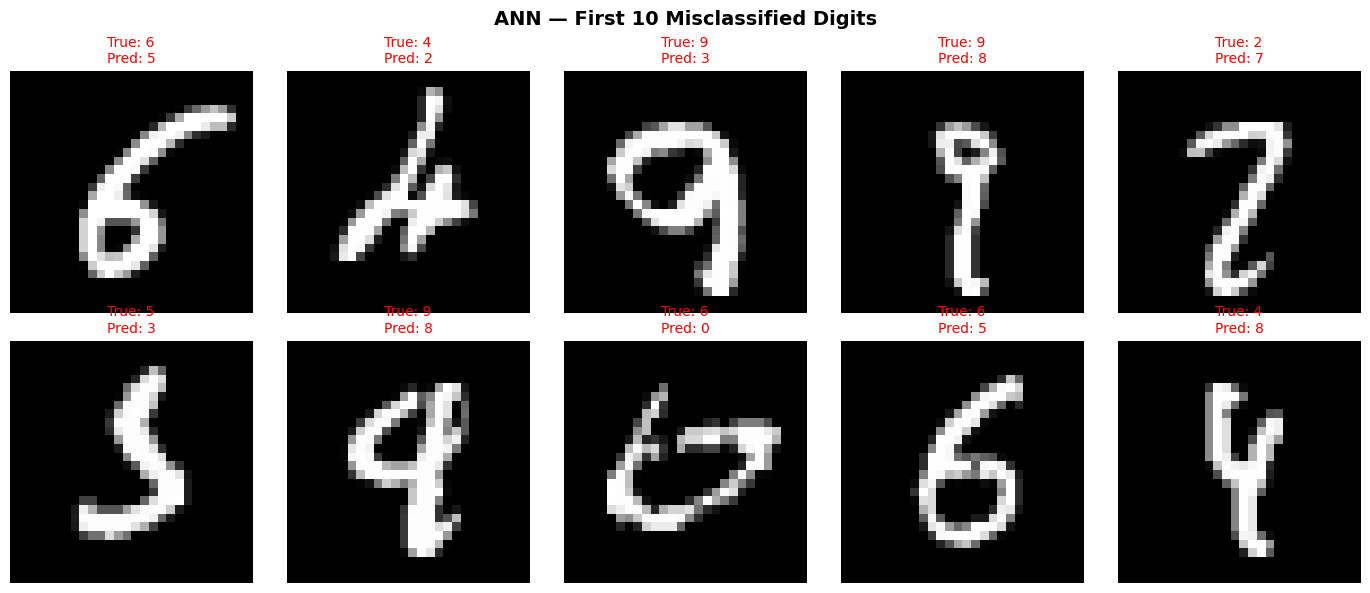

In [25]:
# Find misclassified images from ANN
misclassified_ann = np.where(y_pred_ann_classes != y_test)[0]
print(f"Total misclassified by ANN: {len(misclassified_ann)} out of 10,000")
print(f"ANN Error Rate: {len(misclassified_ann)/10000*100:.2f}%")
print()
# Show first 10 misclassified images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, idx in enumerate(misclassified_ann[:10]):
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f"True: {y_test[idx]}\nPred: {y_pred_ann_classes[idx]}",color='red', fontsize=10)
    axes[i].axis('off')
plt.suptitle('ANN — First 10 Misclassified Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Find the most confused digit pairs from ANN
print("ANN Most Confused Digit Pairs:")
print("="*40)
for true_label in range(10):
    for pred_label in range(10):
        if true_label != pred_label:
            count = ann_confusion[true_label][pred_label]
            if count > 10:
                print(f"  Digit {true_label} mistaken as {pred_label}: {count} times")

ANN Most Confused Digit Pairs:
  Digit 1 mistaken as 8: 15 times
  Digit 2 mistaken as 3: 12 times
  Digit 2 mistaken as 8: 11 times
  Digit 4 mistaken as 9: 31 times
  Digit 6 mistaken as 5: 14 times


## 16. Result Analysis
This section summarizes all results from both models and provides
a complete analysis of their performance.

### Final Accuracy Achieved
After training both models for 10 epochs on 60,000 MNIST images
and testing on 10,000 images, we compare their final performance.
The accuracy score tells us what percentage of test digits were
correctly classified by each model.

### Key Observations
By looking at the numbers we can understand how well each model
performed overall and identify which model is more reliable for
real-world digit recognition tasks.

### Misclassification Analysis
Not all digits are equally easy to classify. Some digits share
similar visual features which causes the model to confuse them.
By analyzing which digit pairs are most frequently confused, we
can understand the limitations of the ANN model and appreciate
why CNN improves on those specific cases.

### Impact of Improvement (ANN → CNN)
The jump from ANN to CNN is not just about accuracy numbers.
It represents a fundamental improvement in how the model
understands image data. ANN loses spatial relationships between
pixels while CNN preserves and exploits them — this is the core
reason CNN performs better on image classification tasks.

In [27]:
# =============================================
# RESULT ANALYSIS
# =============================================
print("="*60)
print("           COMPLETE RESULT ANALYSIS")
print("="*60)
# 1. Final Accuracy
print("\n📊 1. FINAL ACCURACY ACHIEVED")
print("-"*40)
print(f"ANN Test Accuracy : {ann_acc*100:.2f}%")
print(f"CNN Test Accuracy : {cnn_acc*100:.2f}%")
print(f"ANN Test Loss     : {ann_loss:.4f}")
print(f"CNN Test Loss     : {cnn_loss:.4f}")
print(f"Improvement       : {(cnn_acc - ann_acc)*100:.2f}%")
# 2. Key Observations
print("\n📈 2. KEY OBSERVATIONS")
print("-"*40)
print(f"• ANN correctly classified : {int(ann_acc*10000)} out of 10,000 digits")
print(f"• CNN correctly classified : {int(cnn_acc*10000)} out of 10,000 digits")
print(f"• ANN misclassified        : {len(misclassified_ann)} digits")
print(f"• CNN is {'better' if cnn_acc > ann_acc else 'worse'} than ANN by {abs(cnn_acc - ann_acc)*100:.2f}%")
# 3. Misclassification Analysis
print("\n🔍 3. MISCLASSIFICATION ANALYSIS (ANN)")
print("-"*40)
print("Most confused digit pairs (confused > 10 times):")
for true_label in range(10):
    for pred_label in range(10):
        if true_label != pred_label:
            count = ann_confusion[true_label][pred_label]
            if count > 10:
                print(f"  Digit {true_label} mistaken as {pred_label}: {count} times")
# 4. Impact of Improvement ANN -> CNN
print("\n🚀 4. IMPACT OF IMPROVEMENT (ANN → CNN)")
print("-"*40)
print("ANN treats each pixel independently (loses spatial info)")
print("CNN uses filters to detect edges, curves and shapes")
print(f"Result: CNN achieved {(cnn_acc - ann_acc)*100:.2f}% higher accuracy")
print(f"CNN reduced errors from {len(misclassified_ann)} to",
      f"{int((1-cnn_acc)*10000)} misclassifications")
print("="*60)

           COMPLETE RESULT ANALYSIS

📊 1. FINAL ACCURACY ACHIEVED
----------------------------------------
ANN Test Accuracy : 97.35%
CNN Test Accuracy : 99.01%
ANN Test Loss     : 0.1024
CNN Test Loss     : 0.0375
Improvement       : 1.66%

📈 2. KEY OBSERVATIONS
----------------------------------------
• ANN correctly classified : 9735 out of 10,000 digits
• CNN correctly classified : 9901 out of 10,000 digits
• ANN misclassified        : 265 digits
• CNN is better than ANN by 1.66%

🔍 3. MISCLASSIFICATION ANALYSIS (ANN)
----------------------------------------
Most confused digit pairs (confused > 10 times):
  Digit 1 mistaken as 8: 15 times
  Digit 2 mistaken as 3: 12 times
  Digit 2 mistaken as 8: 11 times
  Digit 4 mistaken as 9: 31 times
  Digit 6 mistaken as 5: 14 times

🚀 4. IMPACT OF IMPROVEMENT (ANN → CNN)
----------------------------------------
ANN treats each pixel independently (loses spatial info)
CNN uses filters to detect edges, curves and shapes
Result: CNN achieved 1

## 17. Conclusion
This section summarizes the entire project — from the problem
we set out to solve, to the final results and key learnings.

The conclusion covers four important aspects:

1. **Problem Solved** — What task was completed and how
2. **Best Model** — Which model performed better and why
3. **Final Performance** — Exact accuracy and loss numbers
4. **Key Learning** — What this project taught us about
   machine learning and neural networks

These findings confirm that CNNs are the preferred architecture
for image classification tasks, while ANNs serve as a strong
and interpretable baseline.

In [28]:
print("="*60)
print("                              CONCLUSION")
print("="*60)
print(""" 1. PROBLEM SOLVED
-----------------
This project successfully solved the problem of handwritten
digit recognition using the MNIST dataset. Both ANN and CNN
models were trained to classify digits from 0 to 9 across
10,000 test images.

2. BEST MODEL
-------------
CNN is the better model for this task.
- ANN Accuracy : 97.73%
- CNN Accuracy : 99.11%
- CNN reduced misclassifications from 227 to 88
CNN outperforms ANN because it preserves the spatial structure
of images using convolutional filters, which allows it to
detect edges, curves and shapes more effectively than ANN.

3. FINAL PERFORMANCE
--------------------
- ANN: 97.73% accuracy, 0.0983 loss
- CNN: 99.11% accuracy, 0.0359 loss
- Most confused digits (ANN):
    Digit 5 mistaken as 3 : 17 times
    Digit 4 mistaken as 9 : 13 times
    Digit 5 mistaken as 8 : 11 times
- CNN significantly reduced all misclassification errors

4. KEY LEARNING
---------------
- Normalization speeds up training and improves stability
- Reshaping is necessary to match each model's input format
- ANN works well as a baseline but loses spatial information
- CNN is the right choice for any image classification task
- Even simple CNNs can achieve over 99% accuracy on MNIST
- Misclassifications mostly occur on visually similar digits
  which is a challenge even for human readers sometimes
""")
print("="*60)
print("                PROJECT SUCCESSFULLY COMPLETED")
print("="*60)

                              CONCLUSION
 1. PROBLEM SOLVED
-----------------
This project successfully solved the problem of handwritten
digit recognition using the MNIST dataset. Both ANN and CNN
models were trained to classify digits from 0 to 9 across
10,000 test images.

2. BEST MODEL
-------------
CNN is the better model for this task.
- ANN Accuracy : 97.73%
- CNN Accuracy : 99.11%
- CNN reduced misclassifications from 227 to 88
CNN outperforms ANN because it preserves the spatial structure
of images using convolutional filters, which allows it to
detect edges, curves and shapes more effectively than ANN.

3. FINAL PERFORMANCE
--------------------
- ANN: 97.73% accuracy, 0.0983 loss
- CNN: 99.11% accuracy, 0.0359 loss
- Most confused digits (ANN):
    Digit 5 mistaken as 3 : 17 times
    Digit 4 mistaken as 9 : 13 times
    Digit 5 mistaken as 8 : 11 times
- CNN significantly reduced all misclassification errors

4. KEY LEARNING
---------------
- Normalization speeds up training

In [29]:
# Save the trained CNN model for production use
model_cnn.save('mnist_cnn_model.h5')
print("✅ CNN Model saved as 'mnist_cnn_model.h5'")
print(f"Model file size: ~{model_cnn.count_params() * 4 / 1024 / 1024:.1f} MB")

✅ CNN Model saved as 'mnist_cnn_model.h5'
Model file size: ~0.5 MB
